<>:18: SyntaxWarning: invalid escape sequence '\$'
<>:19: SyntaxWarning: invalid escape sequence '\$'
<>:18: SyntaxWarning: invalid escape sequence '\$'
<>:19: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_14003/3100445661.py:18: SyntaxWarning: invalid escape sequence '\$'
  df["Assessed Value"] = df["Assessed Value"].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipykernel_14003/3100445661.py:19: SyntaxWarning: invalid escape sequence '\$'
  df["Sale Amount"] = df["Sale Amount"].replace('[\$,]', '', regex=True).astype(float)


Shape: (251976, 13)

Columns:
 Index(['Serial Number', 'List Year', 'Date Recorded', 'Town', 'Address',
       'Assessed Value', 'Sale Amount', 'Sales Ratio', 'Property Type',
       'Residential Type', 'Assessor Remarks', 'OPM remarks', 'Location'],
      dtype='object')

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251976 entries, 0 to 251975
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Serial Number     251976 non-null  int64  
 1   List Year         251976 non-null  int64  
 2   Date Recorded     251976 non-null  object 
 3   Town              251976 non-null  object 
 4   Address           251976 non-null  object 
 5   Assessed Value    251976 non-null  object 
 6   Sale Amount       251976 non-null  object 
 7   Sales Ratio       251976 non-null  float64
 8   Property Type     198307 non-null  object 
 9   Residential Type  189777 non-null  object 
 10  Assessor Remarks  17178 non

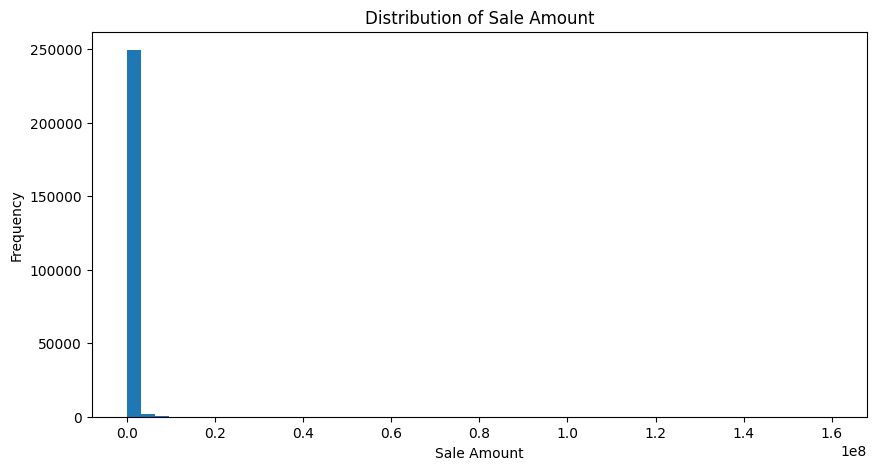

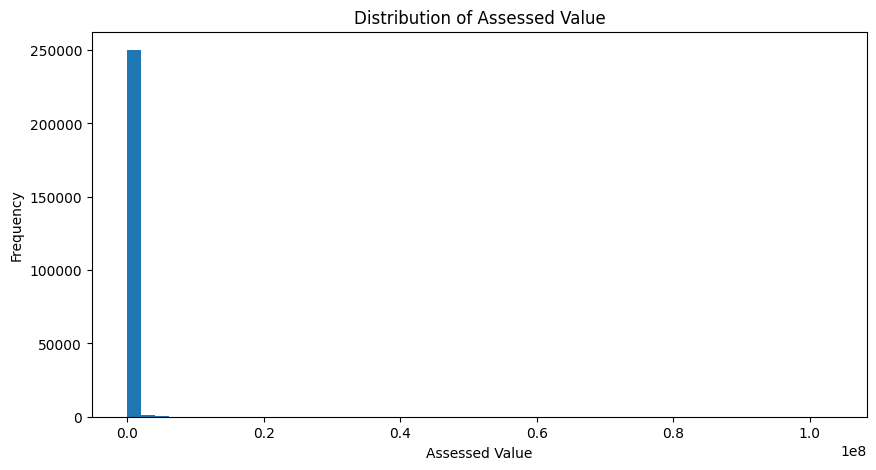

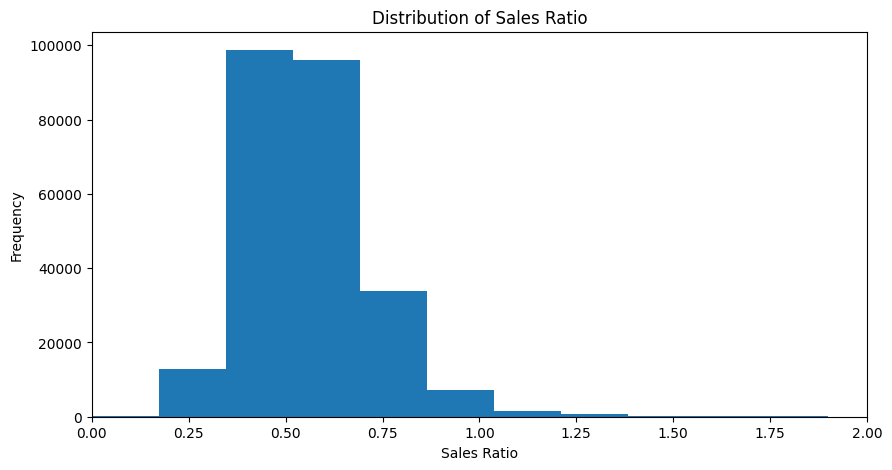

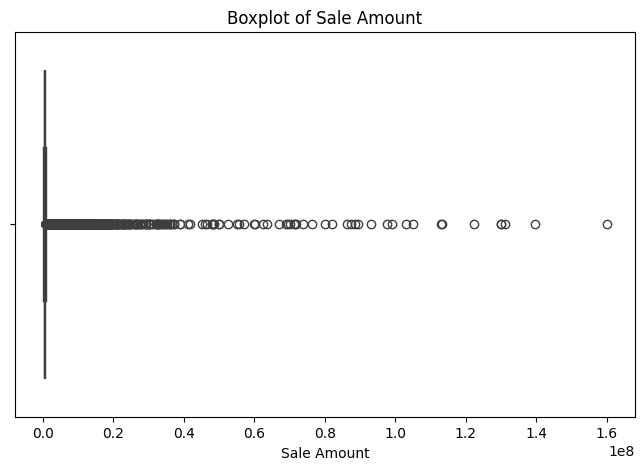

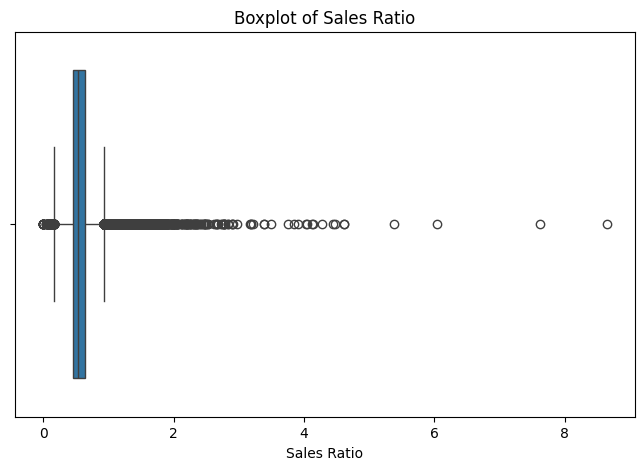

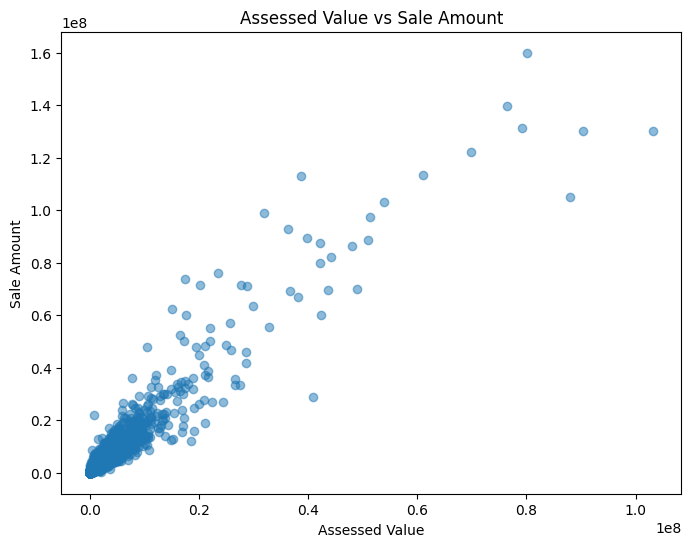


Correlation Matrix:

                Assessed Value  Sale Amount  Sales Ratio
Assessed Value        1.000000     0.953595     0.055165
Sale Amount           0.953595     1.000000    -0.026658
Sales Ratio           0.055165    -0.026658     1.000000

Sales Ratio Summary:

count    251976.000000
mean          0.560531
std           0.169007
min           0.000000
25%           0.453500
50%           0.537400
75%           0.644600
max           8.640100
Name: Sales Ratio, dtype: float64


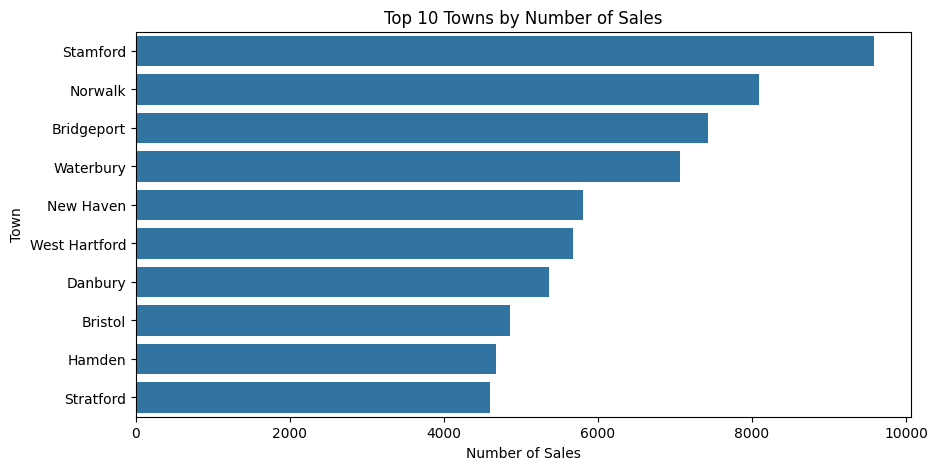

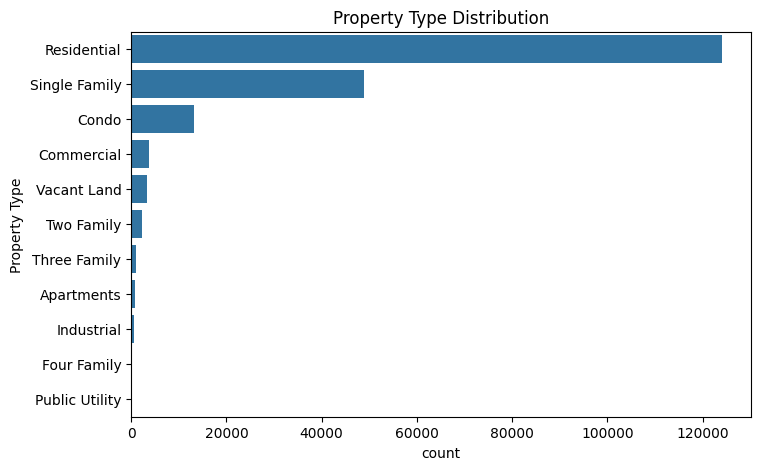

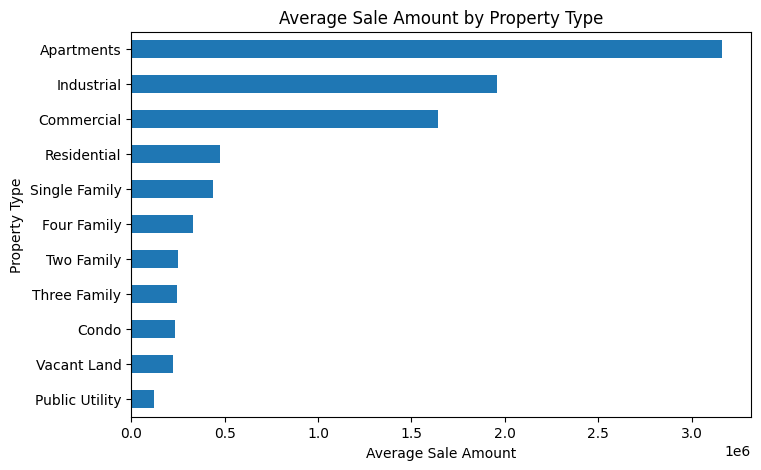

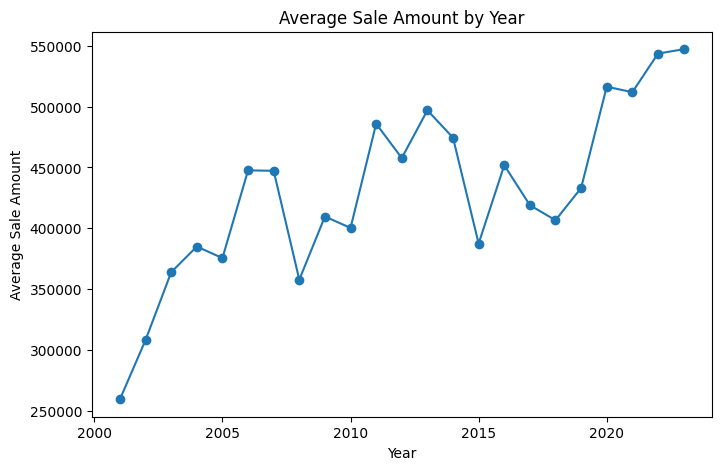

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("cleaned_real_estate_data.csv")

#overview of shape, columns, and info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:\n")
print(df.info())

print("\nMissing Values:\n", df.isnull().sum())

#ensuring numeric columns are floats
df["Assessed Value"] = df["Assessed Value"].replace('[\$,]', '', regex=True).astype(float)
df["Sale Amount"] = df["Sale Amount"].replace('[\$,]', '', regex=True).astype(float)

#summary statistics (using describe)
print("\nNumerical Summary:\n")
print(df.describe())
print("\nMedian Values:\n")
print(df[["Assessed Value", "Sale Amount", "Sales Ratio"]].median())

#distribution plots

#sales amount dist plot
plt.figure(figsize=(10,5))
plt.hist(df["Sale Amount"], bins=50)
plt.title("Distribution of Sale Amount")
plt.xlabel("Sale Amount")
plt.ylabel("Frequency")
plt.show()

#assessed value dist plot
plt.figure(figsize=(10,5))
plt.hist(df["Assessed Value"], bins=50)
plt.title("Distribution of Assessed Value")
plt.xlabel("Assessed Value")
plt.ylabel("Frequency")
plt.show()

#sales ratio
plt.figure(figsize=(10,5))
plt.hist(df["Sales Ratio"], bins=50)
plt.title("Distribution of Sales Ratio")
plt.xlabel("Sales Ratio")
plt.ylabel("Frequency")
plt.xlim(0, 2)
plt.show()

#boxplots of sale amounts (examine for outliers)
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Sale Amount"])
plt.title("Boxplot of Sale Amount")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Sales Ratio"])
plt.title("Boxplot of Sales Ratio")
plt.show()

#assessed vs. sale price plot
plt.figure(figsize=(8,6))
plt.scatter(df["Assessed Value"], df["Sale Amount"], alpha=0.5)
plt.title("Assessed Value vs Sale Amount")
plt.xlabel("Assessed Value")
plt.ylabel("Sale Amount")
plt.show()

#correlation matrix to determine corr between assessed value and sale
print("\nCorrelation Matrix:\n")
print(df[["Assessed Value", "Sale Amount", "Sales Ratio"]].corr())

#sales ration summary summary statistics
print("\nSales Ratio Summary:\n")
print(df["Sales Ratio"].describe())

#top 10 towns by sales
top_towns = df["Town"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_towns.values, y=top_towns.index)
plt.title("Top 10 Towns by Number of Sales")
plt.xlabel("Number of Sales")
plt.ylabel("Town")
plt.show()

#property type analysis
plt.figure(figsize=(8,5))
sns.countplot(data=df, y="Property Type", order=df["Property Type"].value_counts().index)
plt.title("Property Type Distribution")
plt.show()

#average sale price by property type
avg_price = df.groupby("Property Type")["Sale Amount"].mean().sort_values()

plt.figure(figsize=(8,5))
avg_price.plot(kind="barh")
plt.title("Average Sale Amount by Property Type")
plt.xlabel("Average Sale Amount")
plt.show()

#time trend (by year)
yearly_sales = df.groupby("List Year")["Sale Amount"].mean()

plt.figure(figsize=(8,5))
plt.plot(yearly_sales.index, yearly_sales.values, marker="o")
plt.title("Average Sale Amount by Year")
plt.xlabel("Year")
plt.ylabel("Average Sale Amount")
plt.show()